# OCPM analysis
In this notebook, we analyse the generated OCELs using OCPM and our novel split-tree-mining approach

In [68]:
import pm4py
import pandas as pd
import os, json
from collections import defaultdict

In [69]:
class Split_tree:
    def __init__(self,root):
        self.root = root
        self.nodes = [root]
        self.leaves = []
        self.splits = 0
    
    

## Combine traces to coherent OCEL

In [70]:
complete_ocel_json = {}
complete_ocel_json["objects"] = []
complete_ocel_json["events"] =[]
o_count = 0
path = "../Output/"
json_files = [pos_json for pos_json in os.listdir(path) if pos_json.endswith('.json')]
with open(os.path.join(path,json_files[0])) as init_js:
    json_text = json.load(init_js)
    complete_ocel_json["objectTypes"]= json_text["objectTypes"]
    complete_ocel_json["eventTypes"]= json_text["eventTypes"]

for index, js in enumerate(json_files):
    with open(os.path.join(path, js)) as json_file:
        json_ocel = json.load(json_file)
        o_count += len(json_ocel["objects"])
        complete_ocel_json["objects"] +=(json_ocel["objects"])
        complete_ocel_json["events"]+=(json_ocel["events"])

# Serializing json
json_object = json.dumps(complete_ocel_json)

# Writing to sample.json
with open("OCEL.json", "w") as outfile:
    outfile.write(json_object)

In [71]:
ocel = pm4py.read_ocel2_json("OCEL.json")

## Mine Split trees

1. initialize all items as not visited
2. find all roots via order placed
2. initialise graph for each root
3. get list of all split events
4. iterate over splits, marking item as visited and adding them to queue while adding edges


In [81]:
items = ocel.objects[ocel.objects['ocel:type']=="Item"]["ocel:oid"].unique()
order_placed = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Place Order'])

nested_roots = order_placed.get_extended_table()["ocel:type:Item"].tolist()
roots = []
for nested_root in nested_roots:
    for root in nested_root:
        roots.append(root)

split_list = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()["ocel:type:Item"]
split_dict = {}
for split in split_list:
    split_dict[split[0]] = split[1:]

split_trees={}

for root in roots:
    split_trees[root]=(Split_tree(root))

KeyboardInterrupt: 

In [62]:
for root in roots:
    queue = [root]
    while queue:
        current = queue.pop(0)
        if current in split_dict.keys():
            split_trees[root].nodes += split_dict[current]
            queue += split_dict[current]
            split_trees[root].splits += 1
        else:
            split_trees[root].leaves.append(current)


In [63]:
for root in split_trees.keys():
    if split_trees[root].splits > 1:
        print(root)

item_9_2285
item_45_4912
item_50_6254


In [67]:
split_trees["item_9_2285"].splits

2

In [96]:
ocel.relations[ocel.relations["ocel:eid"]=="e_1_0_5_company_1_0"]

,ocel:eid,ocel:activity,ocel:timestamp,ocel:oid,ocel:type,ocel:qualifier
976,e_1_0_5_company_1_0,Split Item,2025-04-10 08:19:00+00:00,item_1_0_6861,Item,Split item out of stock
977,e_1_0_5_company_1_0,Split Item,2025-04-10 08:19:00+00:00,item_1_0,Item,Split of available items for delivery
978,e_1_0_5_company_1_0,Split Item,2025-04-10 08:19:00+00:00,item_1_0_5948,Item,Split item for delivery


In [82]:
split_list = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()["ocel:type:Item"]

In [87]:
pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,ocel:type:Item
0,e_1_0_5_company_1_2,2025-04-10 08:17:00+00:00,Split Item,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,NaN,"[item_1_2, item_1_2_9371, item_1_2_5966]"
1,e_1_0_5_company_1_0,2025-04-10 08:19:00+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,"[item_1_0_6861, item_1_0, item_1_0_5948]"
2,e_1_0_5_company_1_1,2025-04-10 08:26:00+00:00,Split Item,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,NaN,"[item_1_1_7161, item_1_1_7834, item_1_1]"
3,e_1_1_5_company_1_2,2025-04-12 08:23:00+00:00,Split Item,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,NaN,"[item_1_2_4590, item_1_2_2232, item_1_2_5966]"
4,e_1_1_5_company_1_1,2025-04-12 08:52:00+00:00,Split Item,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,NaN,"[item_1_1_7161, item_1_1_3814, item_1_1_7453]"
5,e_1_2_5_company_1_2,2025-04-18 08:44:00+00:00,Split Item,NaN,NaN,NaN,S. Wilson,NaN,NaN,NaN,NaN,NaN,"[item_1_2_3109, item_1_2_2232, item_1_2_1989]"
6,e_4_0_5_company_1_1,2025-07-16 08:40:00+00:00,Split Item,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,NaN,"[item_4_1_6171, item_4_1, item_4_1_9374]"
7,e_10_0_5_company_1_0,2025-09-27 08:09:00+00:00,Split Item,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,NaN,"[item_10_0, item_10_0_4741, item_10_0_4733]"
8,e_15_0_5_company_1_0,2025-11-22 09:13:00+00:00,Split Item,NaN,NaN,NaN,L. Moore,NaN,NaN,NaN,NaN,NaN,"[item_15_0_8480, item_15_0, item_15_0_6351]"
9,e_16_0_5_company_1_1,2025-12-04 08:39:00+00:00,Split Item,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,NaN,"[item_16_1_5726, item_16_1, item_16_1_9585]"


## Analyse Processes

In [11]:
pm4py.discover_ocdfg(ocel)

{'activities': {'Check Availability',
  'Deliver Package',
  'Load Package',
  'Pack Items',
  'Pick Item',
  'Place Order',
  'Receive Payment',
  'Send Invoice',
  'Split Item',
  'Store Package'},
 'object_types': {'Item', 'Order', 'Package'},
 'edges': {'event_couples': {'Order': {('Place Order',
     'Send Invoice'): {('e_0_1_company_1',
      'e_0_2_company_1'), ('e_10_1_company_1', 'e_10_2_company_1'), ('e_11_1_company_1',
      'e_11_2_company_1'), ('e_12_1_company_1',
      'e_12_2_company_1'), ('e_13_1_company_1', 'e_13_2_company_1'), ('e_14_1_company_1',
      'e_14_2_company_1'), ('e_15_1_company_1',
      'e_15_2_company_1'), ('e_16_1_company_1', 'e_16_2_company_1'), ('e_17_1_company_1',
      'e_17_2_company_1'), ('e_18_1_company_1',
      'e_18_2_company_1'), ('e_19_1_company_1', 'e_19_2_company_1'), ('e_1_1_company_1',
      'e_1_2_company_1'), ('e_20_1_company_1',
      'e_20_2_company_1'), ('e_21_1_company_1', 'e_21_2_company_1'), ('e_22_1_company_1',
      'e_22_2_co

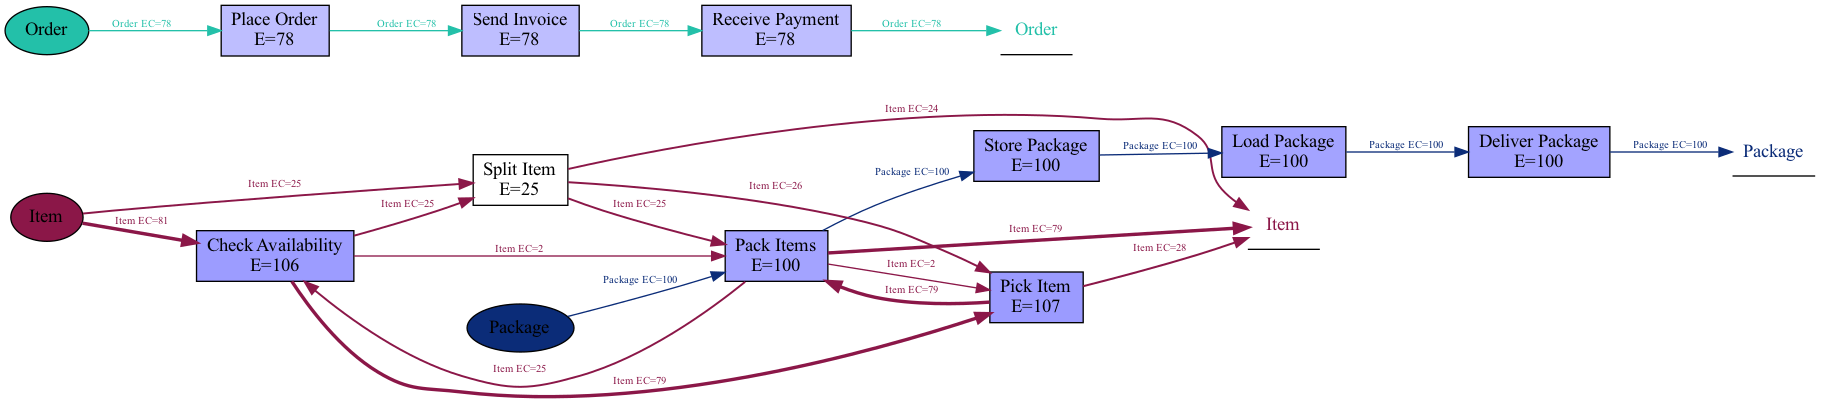

In [72]:
pm4py.view_ocdfg(pm4py.discover_ocdfg(ocel))

In [73]:
filtered_ocel = pm4py.filter_ocel_end_events_per_object_type(
    ocel,
    'Item'
)

In [75]:
filtered_ocel.get_extended_table()

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,ocel:type:Item,ocel:type:Package
0,e_1_0_5_company_1_2,2025-04-10 08:17:00+00:00,Split Item,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,NaN,"[item_1_2, item_1_2_9371, item_1_2_5966]",NaN
1,e_1_0_5_company_1_0,2025-04-10 08:19:00+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,"[item_1_0_6861, item_1_0, item_1_0_5948]",NaN
2,e_1_0_6_company_1_2,2025-04-10 09:14:00+00:00,Pick Item,NaN,NaN,NaN,NaN,S. Wilson,NaN,NaN,NaN,NaN,[item_1_2_9371],NaN
3,e_1_0_6_company_1_0,2025-04-10 09:24:00+00:00,Pick Item,NaN,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,[item_1_0_5948],NaN
4,e_1_0_6_company_1_1,2025-04-10 09:53:00+00:00,Pick Item,NaN,NaN,NaN,NaN,S. Wilson,NaN,NaN,NaN,NaN,[item_1_1_7834],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,e_76_0_8_company_1,2028-01-06 10:40:00+00:00,Pack Items,NaN,NaN,NaN,NaN,NaN,L. Moore,NaN,NaN,NaN,[item_76_1],[package_76_p_9665]
127,e_77_0_8_company_1,2028-01-17 11:19:00+00:00,Pack Items,NaN,NaN,NaN,NaN,NaN,D. Brown,NaN,NaN,NaN,[item_77_0],[package_77_p_7221]
128,e_78_0_8_company_1,2028-01-27 10:41:00+00:00,Pack Items,NaN,NaN,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,[item_78_1],[package_78_p_9191]
129,e_80_0_8_company_1,2028-02-16 09:37:00+00:00,Pack Items,NaN,NaN,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,[item_80_1],[package_80_p_8690]


In [94]:
object_ocel = pm4py.filter_ocel_objects(ocel, ["item_1_0_5948"])

In [95]:
object_ocel.get_extended_table()

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,ocel:type:Item
0,e_1_0_5_company_1_0,2025-04-10 08:19:00+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,[item_1_0_5948]
1,e_1_0_6_company_1_0,2025-04-10 09:24:00+00:00,Pick Item,NaN,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,NaN,[item_1_0_5948]
